# Contrastive learning: views, positives and negatives

CPU companion; no accelerator is required. TPU execution not validated.

- Define the positive pair before augmenting
- Normalize embeddings and introduce temperature
- Verify the changed-condition exercise and explain the limits of this fixture.

Two transformed views belong to the same source example. Can an encoder place them close together without mapping every input to the same point? We will inspect exactly which pairs the objective treats as positives.

## The idea

The lab trains a shared linear encoder with a symmetric cross-view contrastive loss. Each row’s paired view is its positive and other rows are negatives. This resembles the paired objective used in cross-modal retrieval; it is not the full SimCLR denominator, which includes additional same-view negatives.

## Define the positive pair before augmenting

Keep stable source IDs through both view pipelines. The positive for row i must still be the matching source in the other view. Augmentations encode an invariance assumption: a transformation that changes the label can create a false positive. Here small fixed perturbations preserve four explicitly defined directions.

## Normalize embeddings and introduce temperature

Unit-normalize embeddings, compute dot products, and divide by a positive temperature $\tau$. Lower temperature sharpens the categorical comparison. It does not change which pair is correct, and it is not automatically better. A norm floor defines numerical behavior near zero, but zero embeddings are still a collapsed representation.

$$
L=-\frac{1}{2N}\sum_i\left[\log\frac{e^{s_{ii}/\tau}}{\sum_j e^{s_{ij}/\tau}}+\log\frac{e^{s_{ii}/\tau}}{\sum_j e^{s_{ji}/\tau}}\right]
$$

## Check both directions independently

A row asks which right-hand view belongs to a left-hand example; a column asks the reverse question. The code calculates both with a stable host log-sum-exp reference. Check that jointly permuting both views preserves the objective. Permuting only one view without remapping targets should change the task.

## Understand collapse and false negatives

If every embedding is the same, every candidate has equal probability and the loss is $\log N$. That is a useful baseline, not a proof that every gradient path can escape collapse. Distinct source examples may share semantics; treating duplicates as negatives can penalize useful similarity. The cross-modal harness adds a multi-positive objective for that case.

## Separate pretraining evidence from downstream quality

The line records the four-pair training objective, and retrieval is checked on those same pairs. Neither is a linear-probe evaluation. A full representation study freezes the encoder, fits a small supervised probe using training labels and evaluates a held-out split; alternatively compare fine-tuning with random initialization under the same budget. Keep projection-head and encoder outputs distinct.

## Run the example

In [1]:
import jax
import jax.numpy as jnp
import numpy as np

def paired_contrastive(left, right, temperature=.2):
    left = left / jnp.maximum(jnp.linalg.norm(left,axis=-1,keepdims=True),1e-6)
    right = right / jnp.maximum(jnp.linalg.norm(right,axis=-1,keepdims=True),1e-6)
    scores = left @ right.T / temperature
    return -.5*(jnp.mean(jnp.diag(jax.nn.log_softmax(scores,axis=1))) + jnp.mean(jnp.diag(jax.nn.log_softmax(scores,axis=0))))

left=jnp.array([[1.,0.,.2],[0.,1.,-.2],[-1.,0.,.1],[0.,-1.,-.1]])
right=left+jnp.array([[.02,-.01,0.],[-.01,.02,0.],[.01,.01,0.],[-.02,-.01,0.]])
w=jnp.array([[.2,.1],[.1,.1],[.02,-.01]]);history=[]
step=jax.jit(jax.value_and_grad(lambda w:paired_contrastive(left@w,right@w,.2)))
for _ in range(60):
    value,g=step(w);history.append(float(value));w=w-.03*g
assert history[-1]<history[0]
zi=left@w;zt=right@w
zi=zi/jnp.linalg.norm(zi,axis=1,keepdims=True);zt=zt/jnp.linalg.norm(zt,axis=1,keepdims=True)
scores=zi@zt.T/.2
host=np.asarray(scores,dtype=np.float64)
def host_ce(a):
    return np.mean(np.log(np.exp(a-a.max(1,keepdims=True)).sum(1))+a.max(1)-np.diag(a))
np.testing.assert_allclose(paired_contrastive(left@w,right@w,.2),.5*(host_ce(host)+host_ce(host.T)),atol=1e-6)
assert np.array_equal(np.argmax(host,axis=1),np.arange(4))
permutation=jnp.array([2,0,3,1])
np.testing.assert_allclose(paired_contrastive(left@w,right@w),paired_contrastive((left@w)[permutation],(right@w)[permutation]),atol=1e-6)
print('Paired contrastive initial/final:',history[0],history[-1],'; all four nearest pairs correct')


Paired contrastive initial/final: 0.564157247543335 0.013556718826293945 ; all four nearest pairs correct


Expected: Training loss decreases and all four paired views are nearest neighbors.

## Contrastive learning: views, positives and negatives — recorded experiment

Predict: Predict what should change during training and what this curve cannot establish.

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'training objective','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
for panel in visual_data.get('panels',[visual_data]):
    panel['x']=panel['series'][0]['x']


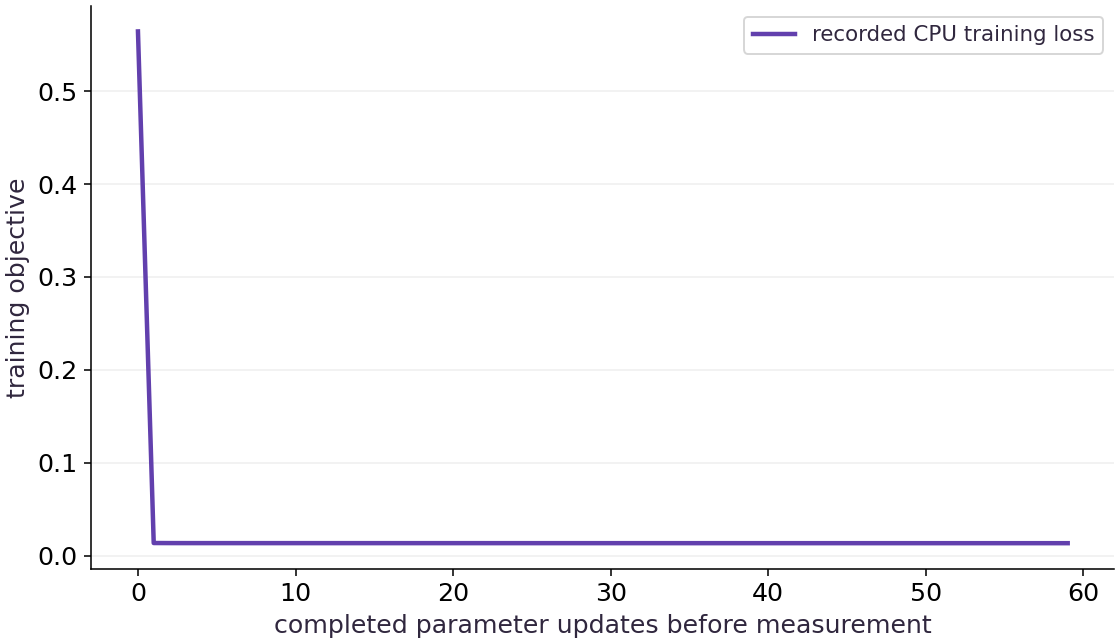

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The line is symmetric cross-view training loss in nats before each update. It falls from about $0.564$ to $0.014$. Lower values mean that the diagonal pair receives more probability among these four candidates, not that semantic accuracy is that number.

### Connect it to the computation

The shared encoder starts with poorly separated directions and learns an embedding where each view retrieves its paired source. The duplicate-pair exercise changes the denominator and reveals why a loss cannot be compared blindly across batch construction policies.

## Measure the collapsed baseline

Predict: What loss should identical embeddings achieve for four candidate pairs?

In [4]:
collapsed=jnp.ones((4,2))
collapse_loss=float(paired_contrastive(collapsed,collapsed))
np.testing.assert_allclose(collapse_loss,np.log(4),atol=1e-6)
print('Collapsed baseline:',collapse_loss)

Collapsed baseline: 1.3862943649291992


Expected: The collapsed loss is log(4), approximately 1.386.

Equal similarity gives each candidate probability one quarter. This baseline catches objectives that reward only attraction and forget competing candidates.

## Your exercise

Permute only the right-hand embeddings after training and demonstrate the effect of broken pair identity.

In [5]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [6]:
wrong_pair_loss=float(paired_contrastive(left@w,(right@w)[permutation]))
assert wrong_pair_loss>float(paired_contrastive(left@w,right@w))
print('Incorrect pair mapping loss:',wrong_pair_loss)

Incorrect pair mapping loss: 7.493563652038574


## Duplicate a source and inspect the objective · Transfer

Duplicate all four pairs while keeping diagonal-only positives. Calculate the change in loss and explain the false-negative effect.

Hint: Each original candidate appears twice, but only one copy is labeled positive.

In [7]:
# Write your attempt here.

## Reference reasoning

The extra log(2) comes from duplicating each denominator candidate without adding the second copy to the positive set. Use source/semantic identity to define multi-positive supervision when appropriate.

In [8]:
duplicated=float(paired_contrastive(jnp.tile(left@w,(2,1)),jnp.tile(right@w,(2,1))))
original=float(paired_contrastive(left@w,right@w))
np.testing.assert_allclose(duplicated-original,np.log(2),atol=1e-5)
print('Duplicated diagonal-only penalty:',duplicated-original)

Duplicated diagonal-only penalty: 0.6931472215801477


## Checkpoint

What does successful retrieval on the training pairs establish?

1. The encoder solves those pairs under that pairing and augmentation contract.
2. A lower training loss by itself proves the full application is ready.
3. Matching shapes alone establishes the required behavior.

## Diagnose

If training stalls near the collapsed baseline, inspect norms and pairing before reducing temperature. Unexpected loss jumps after batching changes can reflect false negatives or a different candidate set.

## Evidence

Keep source pairing, temperature, stable two-direction loss checks, collapse and duplicate baselines, training outputs and broken-pair diagnosis.

## Primary references

- [SimCLR: views and representations](https://arxiv.org/abs/2002.05709)
- [CLIP: symmetric paired contrastive training](https://arxiv.org/abs/2103.00020)